In [1]:

# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 📥 Load Data
df = pd.read_csv('/content/heart.csv')

# 🔎 Quick Data Check
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Decision Tree Classifier

In [2]:
# ✅ Feature & Target
X = df.drop('target', axis=1)
y = df['target']

# 🔀 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🌳 Train Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# 🎯 Predict & Evaluate
y_pred = dtree.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Decision Tree Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Visualize the Decision Tree

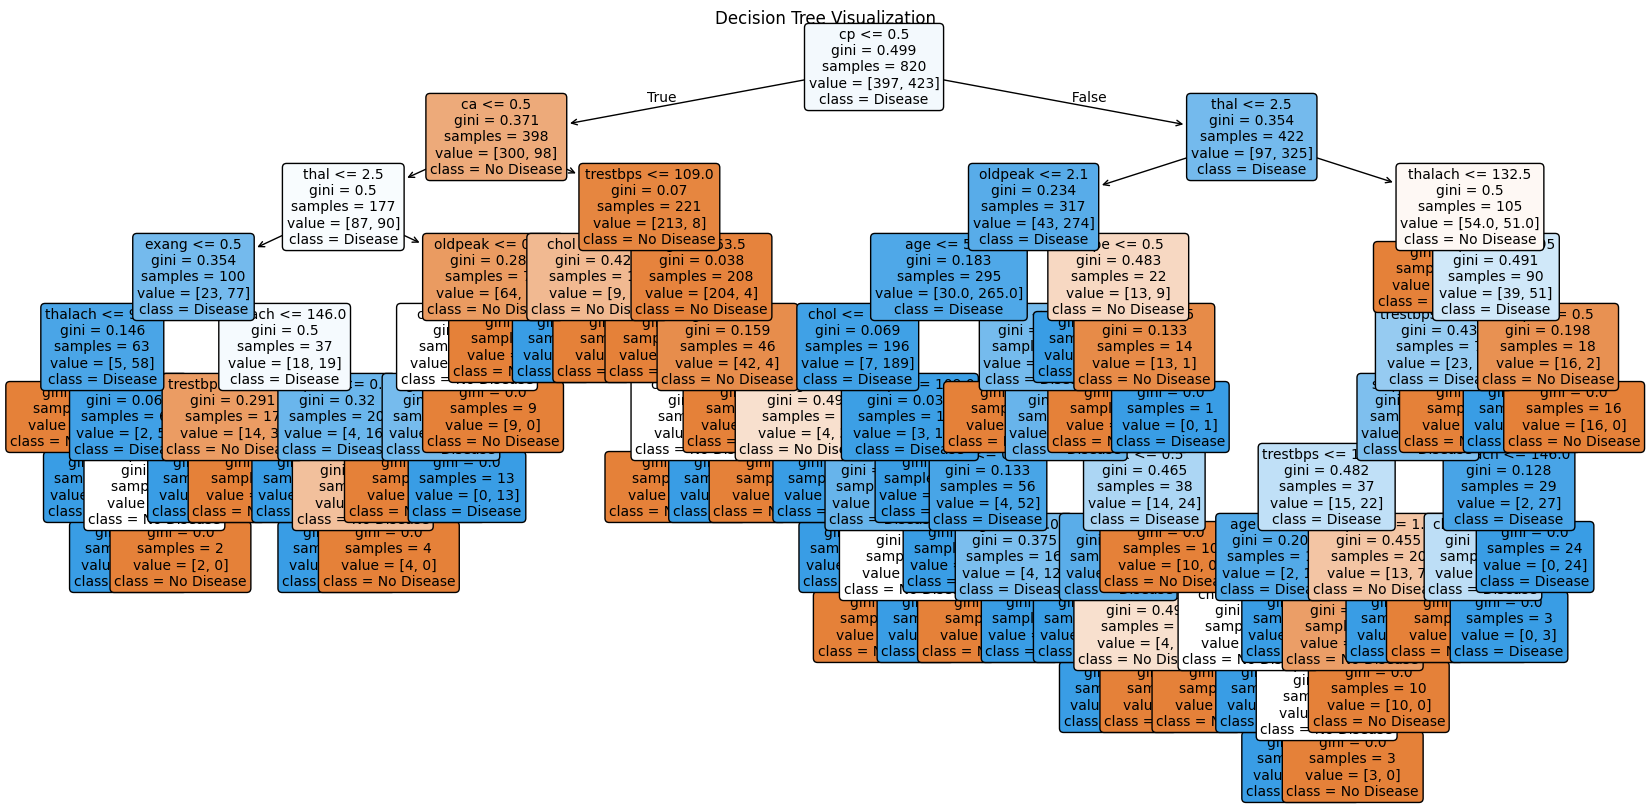

In [3]:
plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization')
plt.show()


Analyze Overfitting & Control Tree Depth

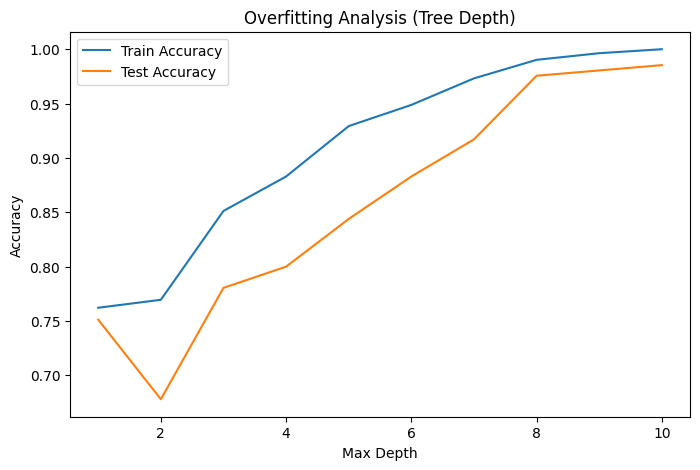

In [4]:
# 🌲 Limiting Depth
depths = range(1, 11)
train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test, y_test))

# 📊 Plot
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Analysis (Tree Depth)')
plt.legend()
plt.show()


 Random Forest Classifier

In [6]:
# 🌲 Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 🎯 Predict & Evaluate
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Feature Importances

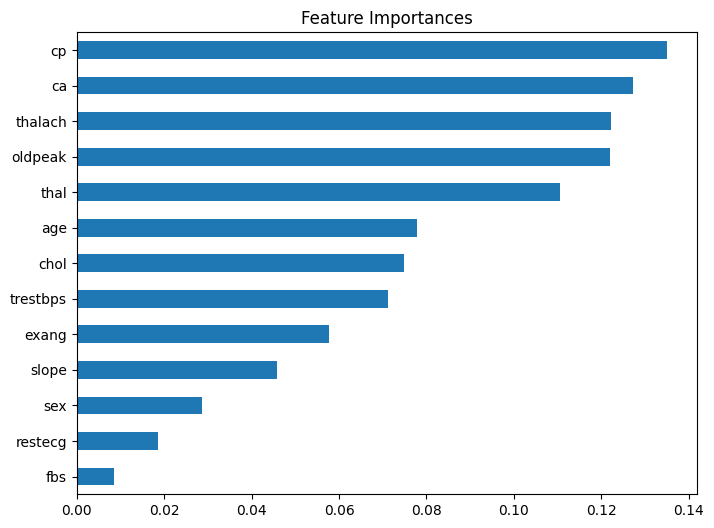

In [7]:
# 📊 Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importances')
plt.show()


Cross-Validation

In [8]:
# 🔄 5-Fold Cross Validation
dt_cv_scores = cross_val_score(dtree, X, y, cv=5)
rf_cv_scores = cross_val_score(rf, X, y, cv=5)

print("Decision Tree CV Accuracy: %.3f ± %.3f" % (dt_cv_scores.mean(), dt_cv_scores.std()))
print("Random Forest CV Accuracy: %.3f ± %.3f" % (rf_cv_scores.mean(), rf_cv_scores.std()))


Decision Tree CV Accuracy: 1.000 ± 0.000
Random Forest CV Accuracy: 0.997 ± 0.006
